In [1]:
import numpy as np
import pandas as pd
import scipy

import soundfile as sf
import simpleaudio as sa
import librosa

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import RectangleSelector

from pathlib import Path
import fsspec

import sys
import re

sys.path.append(f"../src")
import activity.activity_assembly as actvt
from cli import get_file_paths

from core import SITE_NAMES

In [2]:
def add_frequency_group_to_file_dets(file_dets, location_classes):
    file_classes = location_classes[pd.to_datetime(location_classes['file_name'], 
                                                   format='%Y%m%d_%H%M%S.WAV', exact=False)==file_dets.name].copy()
    file_dets.insert(0, 'index_in_summary', file_dets.index)
    file_dets.set_index('index_in_file', inplace=True)
    classified = file_classes['KMEANS_CLASSES']!=''
    file_classes.loc[classified, 'peak_frequency'] = file_classes.loc[classified, 'peak_frequency'].astype('float64')
    file_dets.insert(0, 'peak_frequency', [np.NaN]*len(file_dets))
    file_dets.loc[file_classes['index_in_file'], 'freq_group'] = file_classes['KMEANS_CLASSES'].values
    file_dets.loc[file_classes['index_in_file'], 'peak_frequency'] = file_classes['peak_frequency'].values
    return file_dets

def add_frequency_groups_to_summary_using_kmeans(location_df, file_paths, data_params, save=True):
    location_df.insert(0, 'freq_group', '')
    location_classes = pd.read_csv(Path(file_paths['SITE_classes_file']), index_col=0)
    location_df.insert(0, 'input_file_dt', pd.to_datetime(location_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False))
    location_df_grouped = location_df.groupby('input_file_dt', group_keys=True)
    location_df_classified = location_df_grouped.apply(lambda x: add_frequency_group_to_file_dets(x, location_classes))
    location_df_only_classified = location_df_classified.loc[location_df_classified['freq_group']!='']
    location_df_only_classified = location_df_only_classified.droplevel(level=0)
    location_df_only_classified = location_df_only_classified.reset_index()
    if data_params['type_tag'] != '':
        location_df_only_classified = location_df_only_classified.loc[location_df_only_classified['freq_group']==data_params['type_tag']]
    if save:
        location_df_only_classified.to_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv')
    return location_df_only_classified

def get_dropped_by_kmeans(thresh_file_df, all_file_kmeans_df):
    input_file_group_name = thresh_file_df.input_file.values[0]
    thresh_file_df = thresh_file_df.set_index('index_in_file')
    kmeans_file_df = all_file_kmeans_df[all_file_kmeans_df['input_file']==input_file_group_name]
    kmeans_file_df = kmeans_file_df.set_index('index_in_file')
    dropped_inds = sorted(list(set(thresh_file_df.index) - set(kmeans_file_df.index)))
    return thresh_file_df.loc[dropped_inds]

In [5]:
for site_key in ['Foliage', 'Central', 'Carp', 'Telephone']:
    data_params = dict()
    data_params["site_tag"] = site_key
    data_params["site_name"] = SITE_NAMES[data_params["site_tag"]]
    data_params["type_tag"] = ''
    data_params["detector_tag"] = 'bd2'
    data_params["assembly_type"] = 'kmeans'

    file_paths = get_file_paths(data_params)
    file_paths['SITE_classes_file'] = f"{file_paths['SITE_classes_file'][:-4]}_raw.csv"
    file_paths["SITE_folder"] = file_paths["SITE_folder"].replace("data","data_original")
    raw_location_df_filepath = Path(f'{file_paths["SITE_folder"]}/{data_params["detector_tag"]}__{data_params["site_tag"]}_2022_kmeans_raw.csv')
    print(f'Constructing raw location_df and saving to {raw_location_df_filepath}')
    init_location_sum = actvt.assemble_initial_location_summary(file_paths) 
    init_location_sum.reset_index(inplace=True)
    init_location_sum.rename({'index':'index_in_file'}, axis='columns', inplace=True)
    location_df_kmeans_raw = add_frequency_groups_to_summary_using_kmeans(init_location_sum.copy(), file_paths, data_params, save=False)
    init_location_sum

    file_paths = get_file_paths(data_params)

    raw_calls_df = init_location_sum.copy().sort_values('call_start_time').reset_index()
    raw_calls_df.insert(0, 'input_file_dt', pd.to_datetime(raw_calls_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False))

    raw_per_file_dt = raw_calls_df.groupby('input_file_dt').count()

    fig, ax = plt.subplots(1,1,figsize=(6,4))
    plt.rcParams.update({'font.size':18})
    ax.set_title(f'{data_params["site_name"]}')
    raw_per_file_dt['index'].hist(bins=np.arange(0, 13000, 1000), ax=ax)
    ax.set_xlabel('# of detected calls')
    ax.set_ylabel('# of files')
    ax.set_yscale('log')
    plt.show()

Constructing raw location_df and saving to /Users/adityakrishna/duty-cycle-investigation/src/../data_original/2022_detector_summaries/Foliage/bd2__Foliage_2022_kmeans_raw.csv


OSError: An error occurred while calling the read_csv method registered to the pandas backend.
Original Message: /Users/adityakrishna/duty-cycle-investigation/src/../data/raw/Foliage/bd2__*.csv resolved to no files

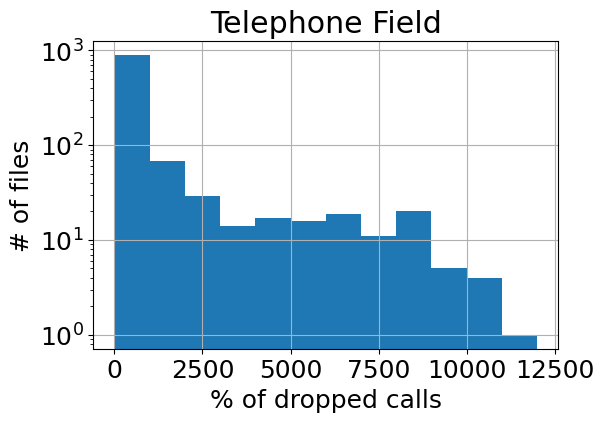

In [4]:
file_paths = get_file_paths(data_params)

raw_calls_df = init_location_sum.copy().sort_values('call_start_time').reset_index()
raw_calls_df.insert(0, 'input_file_dt', pd.to_datetime(raw_calls_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False))

raw_per_file_dt = raw_calls_df.groupby('input_file_dt').count()

fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':18})
ax.set_title(f'{data_params["site_name"]}')
raw_per_file_dt['index'].hist(bins=np.arange(0, 13000, 1000), ax=ax)
# ax.set_xlim(0,1.0)
ax.set_xlabel('% of dropped calls')
ax.set_ylabel('# of files')
ax.set_yscale('log')
plt.show()

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Telephone/bd2__Telephone_2022_kmeans_raw.csv


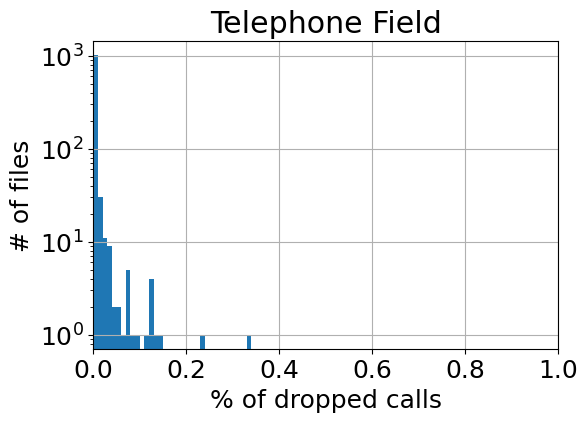

In [5]:
data_params = dict()
data_params["site_tag"] = 'Telephone'
data_params["site_name"] = SITE_NAMES[data_params["site_tag"]]
data_params["type_tag"] = ''
data_params["detector_tag"] = 'bd2'
data_params["assembly_type"] = 'kmeans'

file_paths = get_file_paths(data_params)
file_paths['SITE_classes_file'] = f"{file_paths['SITE_classes_file'][:-4]}_raw.csv"
raw_location_df_filepath = Path(f'{file_paths["SITE_folder"]}/{data_params["detector_tag"]}__{data_params["site_tag"]}_2022_kmeans_raw.csv')
if raw_location_df_filepath.is_file():
    print(f'Reading from {raw_location_df_filepath}')
    location_df_kmeans_raw = pd.read_csv(raw_location_df_filepath, low_memory=False, index_col=0)
else:
    print(f'Constructing raw location_df and saving to {raw_location_df_filepath}')
    init_location_sum = actvt.assemble_initial_location_summary(file_paths) 
    init_location_sum.reset_index(inplace=True)
    init_location_sum.rename({'index':'index_in_file'}, axis='columns', inplace=True)
    location_df_kmeans_raw = add_frequency_groups_to_summary_using_kmeans(init_location_sum.copy(), file_paths, data_params, save=False)
    location_df_kmeans_raw.to_csv(raw_location_df_filepath)

file_paths = get_file_paths(data_params)
location_df_kmeans = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

all_dropped_calls = location_df_kmeans_raw.groupby(by='input_file', group_keys=False).apply(lambda x : get_dropped_by_kmeans(x, location_df_kmeans))

dropped_calls_df = all_dropped_calls.sort_values('call_start_time').reset_index().reset_index()
raw_calls_df = location_df_kmeans_raw.sort_values('call_start_time').reset_index().reset_index()

raw_per_file_dt = raw_calls_df.groupby('input_file_dt').count()
dropped_per_file_dt = dropped_calls_df.groupby('input_file_dt').count()

percentage_dropped_per_file_dt = dropped_per_file_dt['index'].reindex(raw_per_file_dt['index'].index, fill_value=0) / raw_per_file_dt['index']

fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':18})
ax.set_title(f'{data_params["site_name"]}')
percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax)
ax.set_xlim(0,1.0)
ax.set_xlabel('% of dropped calls')
ax.set_ylabel('# of files')
ax.set_yscale('log')
plt.show()

In [6]:
percentage_dropped_per_file_dt.sort_values(ascending=False).head(5)

input_file_dt
2022-09-25 00:00:00    0.333333
2022-08-20 06:30:00    0.231838
2022-10-05 02:00:00    0.142857
2022-07-24 10:30:00    0.131019
2022-08-21 10:30:00    0.127525
Name: index, dtype: float64

In [7]:
raw_per_file_dt['index'].loc[percentage_dropped_per_file_dt.sort_values(ascending=False).head(5).index]

input_file_dt
2022-09-25 00:00:00       3
2022-08-20 06:30:00    1872
2022-10-05 02:00:00       7
2022-07-24 10:30:00     893
2022-08-21 10:30:00     792
Name: index, dtype: int64

In [8]:
dropped_per_file_dt['index'].loc[percentage_dropped_per_file_dt.sort_values(ascending=False).head(5).index]

input_file_dt
2022-09-25 00:00:00      1
2022-08-20 06:30:00    434
2022-10-05 02:00:00      1
2022-07-24 10:30:00    117
2022-08-21 10:30:00    101
Name: index, dtype: int64

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Carp/bd2__Carp_2022_kmeans_raw.csv


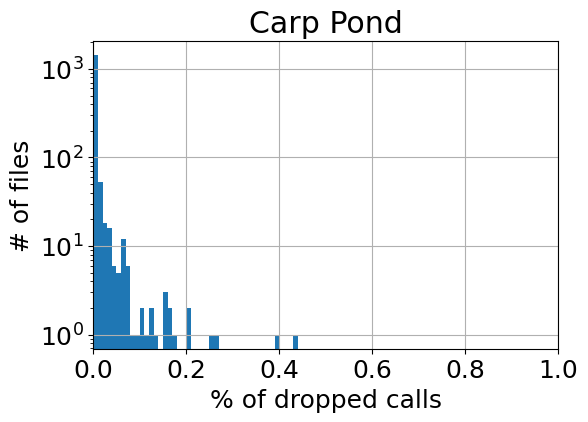

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Foliage/bd2__Foliage_2022_kmeans_raw.csv


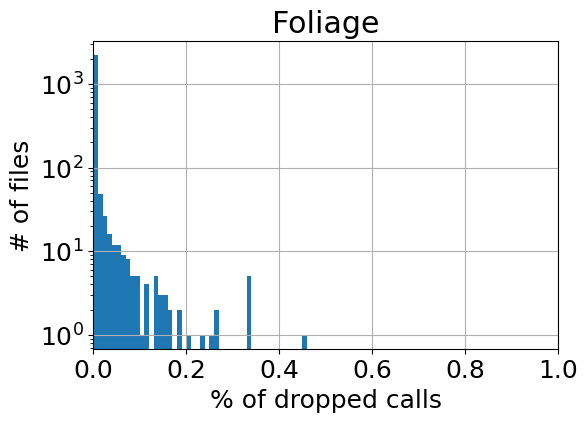

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Central/bd2__Central_2022_kmeans_raw.csv


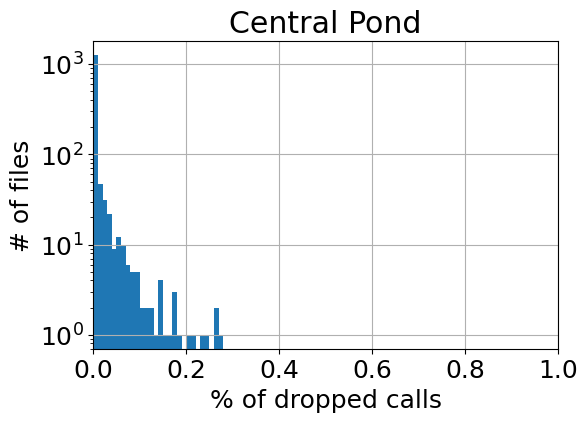

Reading from /Users/adityakrishna/duty-cycle-investigation/src/../data/2022_detector_summaries/Telephone/bd2__Telephone_2022_kmeans_raw.csv


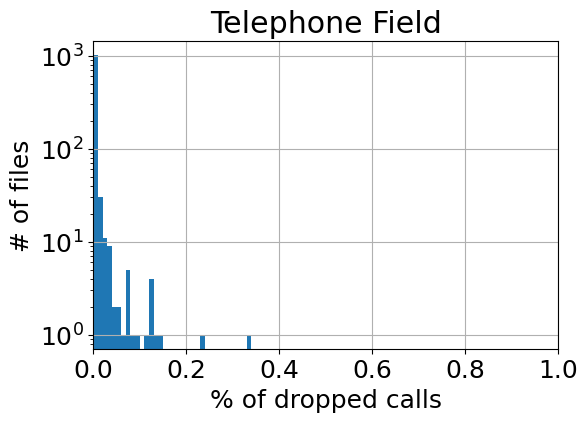

In [9]:
for site_key in ['Carp', 'Foliage', 'Central', 'Telephone']:
    data_params = dict()
    data_params["site_tag"] = site_key
    data_params["site_name"] = SITE_NAMES[data_params["site_tag"]]
    data_params["type_tag"] = ''
    data_params["detector_tag"] = 'bd2'
    data_params["assembly_type"] = 'kmeans'

    file_paths = get_file_paths(data_params)
    file_paths['SITE_classes_file'] = f"{file_paths['SITE_classes_file'][:-4]}_raw.csv"
    raw_location_df_filepath = Path(f'{file_paths["SITE_folder"]}/{data_params["detector_tag"]}__{data_params["site_tag"]}_2022_kmeans_raw.csv')
    if raw_location_df_filepath.is_file():
        print(f'Reading from {raw_location_df_filepath}')
        location_df_kmeans_raw = pd.read_csv(raw_location_df_filepath, low_memory=False, index_col=0)
    else:
        print(f'Constructing raw location_df and saving to {raw_location_df_filepath}')
        init_location_sum = actvt.assemble_initial_location_summary(file_paths) 
        init_location_sum.reset_index(inplace=True)
        init_location_sum.rename({'index':'index_in_file'}, axis='columns', inplace=True)
        location_df_kmeans_raw = add_frequency_groups_to_summary_using_kmeans(init_location_sum.copy(), file_paths, data_params, save=False)
        location_df_kmeans_raw.to_csv(raw_location_df_filepath)

    file_paths = get_file_paths(data_params)
    location_df_kmeans = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    all_dropped_calls = location_df_kmeans_raw.groupby(by='input_file', group_keys=False).apply(lambda x : get_dropped_by_kmeans(x, location_df_kmeans))

    dropped_calls_df = all_dropped_calls.sort_values('call_start_time').reset_index().reset_index()
    raw_calls_df = location_df_kmeans_raw.sort_values('call_start_time').reset_index().reset_index()

    raw_per_file_dt = raw_calls_df.groupby('input_file_dt').count()
    dropped_per_file_dt = dropped_calls_df.groupby('input_file_dt').count()

    percentage_dropped_per_file_dt = dropped_per_file_dt['index'].reindex(raw_per_file_dt['index'].index, fill_value=0) / raw_per_file_dt['index']

    fig, ax = plt.subplots(1,1,figsize=(6,4))
    plt.rcParams.update({'font.size':18})
    ax.set_title(f'{data_params["site_name"]}')
    percentage_dropped_per_file_dt.hist(bins=np.arange(0, 1, 0.01),ax=ax)
    ax.set_xlim(0,1.0)
    ax.set_xlabel('% of dropped calls')
    ax.set_ylabel('# of files')
    ax.set_yscale('log')
    plt.show()